In [7]:
import matplotlib.pyplot as plt
import pandas as pd 
from statsmodels.othermod.betareg import BetaModel
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score

In [33]:
df = pd.read_csv("data/clean/final_featuresv2.csv")

In [43]:
SEED = 42
exclude_cols = ['state', 'date', 'inpatient_beds', 'inpatient_beds_used','inpatient_beds_utilization_coverage','hospital_inpatient_beds_used']
columns_of_interest = [c for c in df.columns if c not in exclude_cols]

df = df[columns_of_interest].dropna().copy()

X = df.drop(columns=['inpatient_beds_utilization'])
y = df["inpatient_beds_utilization"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

In [36]:
X.columns

Index(['on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'icu_patients_confirmed_influenza', 'coverage_per_state',
       'hospital_covid_deaths', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds',
       'hospital_patients_hospitalized_confirmed_influenza_and_covid'],
      dtype='object')

In [46]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Beta regression requires response values strictly in (0, 1)
eps = 1e-6
y_train_beta = y_train.clip(eps, 1 - eps)
y_test_beta = y_test.clip(eps, 1 - eps)

# Scale predictors to help optimizer convergence
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Add intercept
X_train_beta = sm.add_constant(X_train_scaled, has_constant='add')
X_test_beta = sm.add_constant(X_test_scaled, has_constant='add')

# Train on X_train, y_train
beta_model = BetaModel(endog=y_train_beta, exog=X_train_beta)
beta_results = beta_model.fit(method='bfgs', maxiter=1000, disp=False)

# Predict on X_test
y_pred = beta_results.predict(X_test_beta)

# Evaluate on test set
mae = np.mean(np.abs(y_test_beta - y_pred))
rmse = np.sqrt(np.mean((y_test_beta - y_pred) ** 2))
r2 = r2_score(y_test_beta, y_pred)

print(f"Converged: {beta_results.mle_retvals.get('converged', 'unknown')}")
print('\nTest set metrics')
print(f'MAE : {mae:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'R2  : {r2:.6f}')

pred_vs_actual = pd.DataFrame({'y_test': y_test_beta, 'y_pred': y_pred})
pred_vs_actual.head()

Converged: True

Test set metrics
MAE : 0.051006
RMSE: 0.068104
R2  : 0.247280


,y_test,y_pred
35345,0.792474,0.739283
62087,0.669805,0.675746
29306,0.698821,0.668229
24236,0.462252,0.668312
52043,0.751284,0.670236


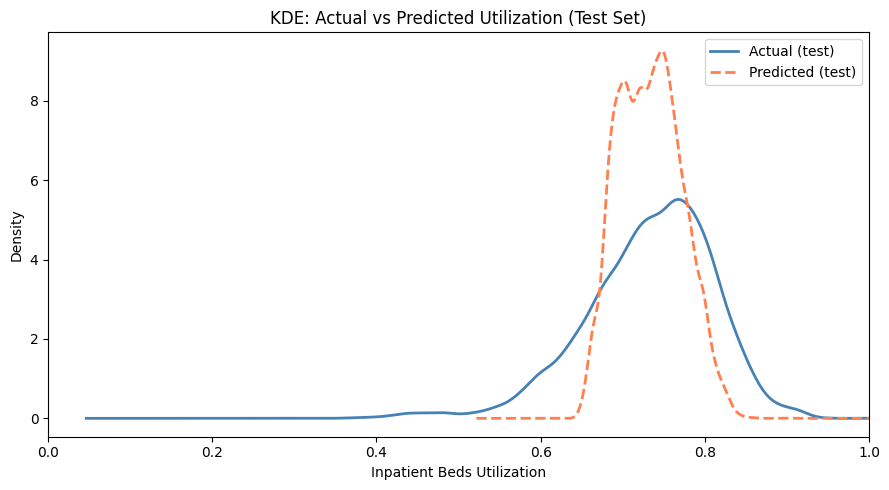

In [48]:
# KDE: predicted vs actual test set distributions
fig, ax = plt.subplots(figsize=(9, 5))

y_test_beta.plot.kde(ax=ax, label='Actual (test)', color='steelblue', linewidth=2)
y_pred.plot.kde(ax=ax, label='Predicted (test)', color='coral', linewidth=2, linestyle='--')

ax.set_xlabel('Inpatient Beds Utilization')
ax.set_ylabel('Density')
ax.set_title('KDE: Actual vs Predicted Utilization (Test Set)')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()